# Apple Product Pricing Intelligence — Analysis

**Question:** How are Apple products priced on Amazon and Flipkart from launch to end of life, what do
sale events, new launches, platform and condition really do to the price, and can we forecast the
price 7 and 30 days ahead well enough to tell a buyer whether to buy now or wait?

**Data:** 80,000 listing snapshots · 31 models · 4 categories · 2 marketplaces · Sep 2020 – Jul 2026 (USD).

This notebook is the analysis layer. It reads the tested dbt marts built by the pipeline
(`python -m apple_pricing.pipeline`), so every number here matches the dashboard and Power BI.

**Contents**
1. Data sources and quality
2. Price level and value retention by category
3. Depreciation curve — the annual staircase
4. The successor-launch cliff
5. Sale events — headline vs real savings
6. Amazon vs Flipkart
7. New vs refurbished
8. Stock status — a confounding trap
9. Price forecasting (7 and 30 days)
10. Buy-now / wait recommendations
11. Conclusions, recommendations and limitations

In [1]:
import json
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))
sys.path.insert(0, str(PROJECT_DIR))

from dashboard.theme import CATEGORY_COLORS, CATEGORY_ORDER, PLATFORM_COLORS, SERIES

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.width", 160)

FIGURES = PROJECT_DIR / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7", "grid.color": "#e1e0d9", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 13, "axes.titlelocation": "left", "figure.dpi": 110,
})

con = duckdb.connect(str(PROJECT_DIR / "warehouse" / "apple_pricing.duckdb"), read_only=True)
sql = lambda query: con.sql(query).df()

def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=160, bbox_inches="tight")

## 1. Data sources and quality

The raw CSV is landed as year-partitioned Parquet (the S3 layout), loaded to `raw.apple_prices`, and
transformed by dbt into a star schema plus analytics marts. Every model is covered by dbt tests
(uniqueness, accepted values, ranges, referential integrity, and business rules such as
*reported discount = (MSRP − price) / MSRP*).

In [2]:
tables = sql("""
    select schema_name, table_name, estimated_size as rows
    from duckdb_tables()
    where schema_name in ('raw', 'marts', 'ml', 'reference')
    order by schema_name, table_name
""")
tables

,schema_name,table_name,rows
0,marts,dim_date,2221
1,marts,dim_product,31
2,marts,fct_daily_market_prices,58611
3,marts,fct_price_observations,80000
4,marts,mart_deal_scores,124
5,marts,mart_depreciation_curve,488
6,marts,mart_forecast_backtest,14793
7,marts,mart_model_scorecard,31
8,marts,mart_platform_price_gap,12669
9,marts,mart_sale_event_impact,20


In [3]:
quality = sql("""
    select
        (select count(*) from raw.apple_prices)                                   as raw_rows,
        (select count(*) from marts.fct_price_observations)                       as clean_rows,
        (select count(*) from marts.fct_daily_market_prices)                      as series_days,
        (select count(*) from raw.apple_prices) -
        (select count(*) from marts.fct_daily_market_prices)                      as extra_listings_same_series_day,
        (select count(*) from staging.stg_apple_prices
          where abs(reported_discount_pct - discount_pct) > 0.15)                 as discount_mismatches,
        (select count(distinct model_name) from marts.fct_price_observations)     as models
""")
quality.T.rename(columns={0: "value"})

,value
raw_rows,80000
clean_rows,80000
series_days,58611
extra_listings_same_series_day,21389
discount_mismatches,0
models,31


In [4]:
dbt_results = pd.read_parquet(PROJECT_DIR / "data" / "marts" / "dbt_run_results.parquet")
dbt_results.groupby(["resource_type", "status"]).size().rename("nodes").to_frame()

,,nodes
resource_type,status,
model,success,13
seed,success,1
test,pass,64


**Findings.** No rows are invalid or duplicated, and the reported discount always matches the prices.
The feed has ~1.4 listings per series-day (21,389 extra rows share a date × platform × model × condition),
so all time-series work uses the **series-day** grain (`fct_daily_market_prices`, 58,611 rows).

**Caveat — the dataset looks simulated.** A few patterns are too clean for scraped marketplace data
(checked below): ratings are uncorrelated with review counts, and Amazon is cheaper on almost exactly
half of matched days. The conclusions describe this dataset; the pipeline itself would run unchanged
on real scraped prices.

In [5]:
obs = sql("select * from marts.fct_price_observations")
print("Spearman(rating, reviews_count):", round(obs[["rating", "reviews_count"]].corr("spearman").iloc[0, 1], 3))
print("Listings per platform:", obs["platform"].value_counts().to_dict())

Spearman(rating, reviews_count): 0.003
Listings per platform: {'Flipkart': 40043, 'Amazon': 39957}


## 2. Price level and value retention by category

In [6]:
category = (
    obs.groupby("product_category")
    .agg(listings=("current_price_usd", "size"),
         avg_price=("current_price_usd", "mean"),
         median_price_index=("price_index", "median"),
         avg_discount_vs_msrp=("discount_pct", "mean"),
         above_msrp_pct=("is_above_msrp", "mean"))
    .assign(above_msrp_pct=lambda d: d["above_msrp_pct"] * 100)
    .loc[CATEGORY_ORDER]
)
category

,listings,avg_price,median_price_index,avg_discount_vs_msrp,above_msrp_pct
product_category,,,,,
iPhone,28589,758.67,82.01,19.57,12.91
iPad,15526,573.08,71.38,26.19,8.59
Mac,18020,"1,382.49",88.77,15.43,11.07
Watch,17865,398.64,75.07,26.27,10.50


Mac is the most expensive category **and** holds value best (median price index ≈ 89, i.e. 11% below MSRP
across its life), while iPad and Watch trade ~25–29% below MSRP on average. About 11% of listings sit up to
2% *above* MSRP, and 99.7% of those are in the first year after launch.

## 3. Depreciation curve — the annual staircase

Age is measured from Apple's **official release date** (from the `product_catalog` seed), not from the first
day a product appears in the data, so older products are placed correctly in their life cycle.

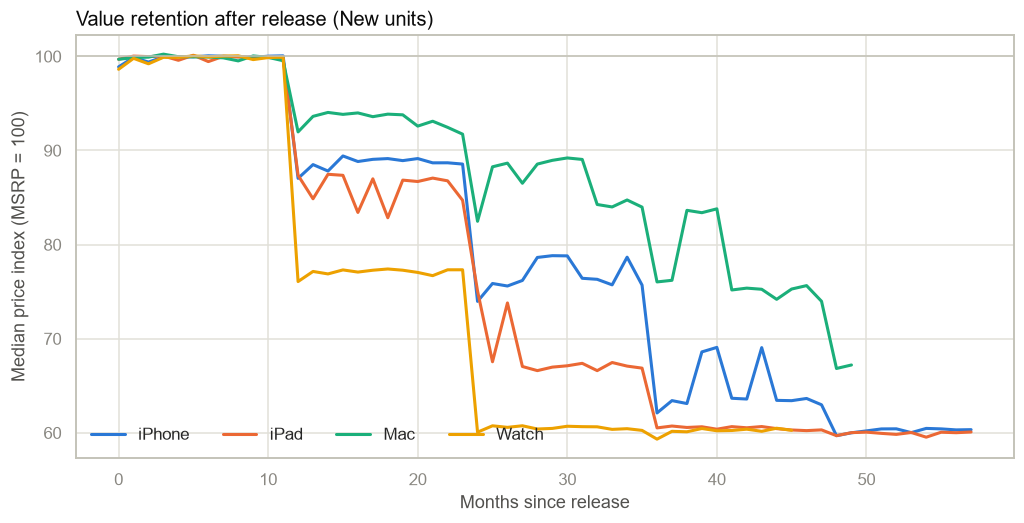

In [7]:
curve = sql("""
    select * from marts.mart_depreciation_curve
    where condition = 'New' and models >= 2 and series_days >= 60
""")

fig, ax = plt.subplots(figsize=(11, 5))
for cat in CATEGORY_ORDER:
    part = curve[curve["product_category"] == cat].sort_values("months_since_release")
    ax.plot(part["months_since_release"], part["median_price_index"], color=CATEGORY_COLORS[cat], lw=2, label=cat)
ax.axhline(100, color="#c3c2b7", lw=1)
ax.set(title="Value retention after release (New units)", xlabel="Months since release",
       ylabel="Median price index (MSRP = 100)")
ax.legend(frameon=False, ncol=4, loc="lower left")
save(fig, "depreciation_curve")
plt.show()

In [8]:
milestones = (
    curve.groupby("product_category")
    .apply(lambda g: pd.Series({
        "index_at_12m": g.loc[g["months_since_release"] == 12, "median_price_index"].squeeze(),
        "index_at_24m": g.loc[g["months_since_release"] == 24, "median_price_index"].squeeze(),
        "index_at_36m": g.loc[g["months_since_release"] == 36, "median_price_index"].squeeze(),
        "first_month_below_90": g.loc[g["median_price_index"] < 90, "months_since_release"].min(),
        "first_month_below_80": g.loc[g["median_price_index"] < 80, "months_since_release"].min(),
    }), include_groups=False)
    .loc[CATEGORY_ORDER]
)
milestones

,index_at_12m,index_at_24m,index_at_36m,first_month_below_90,first_month_below_80
product_category,,,,,
iPhone,87.04,73.96,62.11,12.00,24.00
iPad,87.36,75.07,60.52,12.00,24.00
Mac,91.97,82.48,76.03,24.00,36.00
Watch,76.07,60.07,59.33,12.00,12.00


**Finding — prices don't erode smoothly; they fall in annual steps.** iPhone, iPad and Watch trade at MSRP
for ~11 months, then drop at months 12, 24 and 36 — exactly when the next generation ships — and flatten
at ~60% of MSRP after three years. Mac follows the same shape but with much smaller steps, staying above
90% for two years.

**Implication:** for iPhone/iPad/Watch there is almost no in-year discount on a current model outside sale
events; the big price change is event-driven (the successor launch), which the next section quantifies.

## 4. The successor-launch cliff

In [9]:
successor = sql("select * from marts.mart_successor_launch_impact order by price_change_pct")
successor[["model_name", "product_category", "successor_model_name", "index_60d_before",
           "index_0_59d_after", "price_change_pct"]]

,model_name,product_category,successor_model_name,index_60d_before,index_0_59d_after,price_change_pct
0,Apple Watch Series 9 (45mm),Watch,Apple Watch Series X (45mm),99.81,73.71,-26.16
1,Apple Watch Series 8 (45mm),Watch,Apple Watch Series 9 (45mm),98.58,73.99,-24.95
2,iPhone 15 128GB,iPhone,iPhone 16 128GB,100.04,81.83,-18.20
3,iPhone 14 128GB,iPhone,iPhone 15 128GB,99.18,81.49,-17.84
4,Apple Watch Series 6 (44mm),Watch,Apple Watch Series 7 (45mm),91.03,74.88,-17.74
5,iPhone 16 128GB,iPhone,iPhone 17 128GB,100.11,82.90,-17.20
6,Apple Watch Ultra,Watch,Apple Watch Ultra 2,100.01,83.28,-16.73
7,iPad Pro 11-inch (M1) 128GB,iPad,iPad Pro 11-inch (M4) 256GB,75.15,63.41,-15.62
8,iPhone 14 Pro 128GB,iPhone,iPhone 15 Pro Max 256GB,99.31,84.36,-15.05
9,iPhone 13 128GB,iPhone,iPhone 14 128GB,99.86,85.23,-14.65


In [10]:
stat, p_value = wilcoxon(successor["index_60d_before"], successor["index_0_59d_after"])
by_cat = successor.groupby("product_category")["price_change_pct"].agg(["mean", "median", "count"]).loc[CATEGORY_ORDER]
print(f"Wilcoxon signed-rank (before vs after, n={len(successor)} models): p = {p_value:.5f}")
by_cat

Wilcoxon signed-rank (before vs after, n=21 models): p = 0.00010


,mean,median,count
product_category,,,
iPhone,-14.56,-14.65,9
iPad,-7.88,-7.88,2
Mac,-0.13,0.30,5
Watch,-19.98,-17.74,5


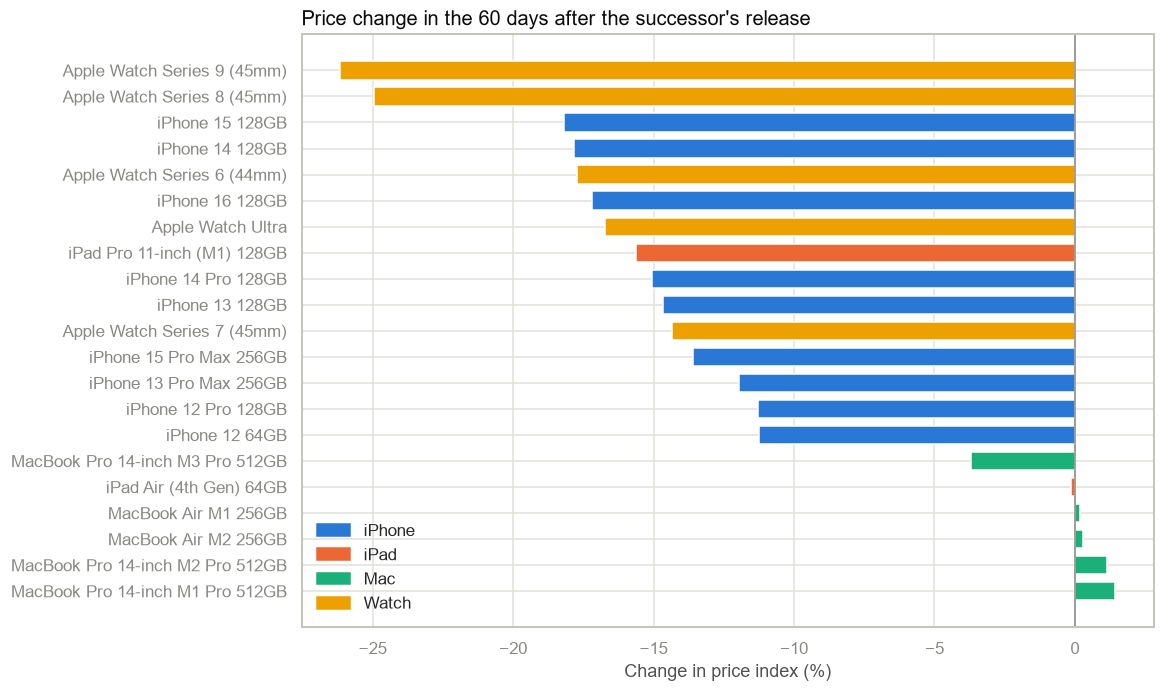

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
ordered = successor.sort_values("price_change_pct", ascending=False)
ax.barh(ordered["model_name"], ordered["price_change_pct"],
        color=ordered["product_category"].map(CATEGORY_COLORS), height=0.7)
ax.axvline(0, color="#898781", lw=1)
ax.set(title="Price change in the 60 days after the successor's release", xlabel="Change in price index (%)", ylabel="")
handles = [plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[c]) for c in CATEGORY_ORDER]
ax.legend(handles, CATEGORY_ORDER, frameon=False, loc="lower left")
save(fig, "successor_launch_impact")
plt.show()

**Finding.** When the successor launches, the previous model's price drops by **~15% for iPhone and ~20% for
Apple Watch** within 60 days (significant across models, Wilcoxon p ≈ 0.0001). Mac prices barely react
(≈ 0%) — Macs depreciate gradually instead.

**Recommendation for buyers:** the cheapest moment to buy last year's iPhone or Watch is the first two months
after the new one ships. For sellers/retailers: clear inventory of the outgoing model *before* launch day.

## 5. Sale events — headline vs real savings

Three increasingly rigorous ways to measure what a sale is worth:

1. **Headline discount vs launch MSRP** — what marketing shows; includes normal depreciation.
2. **Saving vs the product's normal price** — current price vs the mean of the previous 30 *non-event*
   observations of the same series (built leakage-free in dbt).
3. **Regression-adjusted effect** — log price on event dummies with model fixed effects, age, platform,
   condition, stock status, month and year controls (HC3 robust errors).

In [12]:
events = sql("select * from marts.mart_sale_event_impact")
w = lambda g, col: np.average(g[col], weights=g["series_days"])
event_summary = (
    events.groupby("sale_event")
    .apply(lambda g: pd.Series({
        "series_days": g["series_days"].sum(),
        "headline_vs_msrp_pct": w(g, "avg_discount_vs_msrp_pct"),
        "saving_vs_normal_pct": w(g, "avg_savings_vs_baseline_pct"),
        "days_saving_5pct_plus": w(g, "pct_days_saving_5pct_plus"),
    }), include_groups=False)
    .sort_values("saving_vs_normal_pct", ascending=False)
)
event_summary

,series_days,headline_vs_msrp_pct,saving_vs_normal_pct,days_saving_5pct_plus
sale_event,,,,
Big Billion Days,"1,162.00",38.69,24.75,99.23
Great Indian Festival,"1,084.00",35.08,20.70,98.71
Prime Day,783.00,36.04,17.68,97.83
Black Friday,"1,829.00",32.92,16.00,98.74
No Event,"53,616.00",22.17,0.99,13.38


In [13]:
obs["log_price"] = np.log(obs["current_price_usd"])
obs["age_years"] = (obs["days_since_release"] // 365).clip(0, 5)
obs["month"] = obs["price_date"].dt.month
obs["year"] = obs["price_date"].dt.year

regression = smf.ols(
    "log_price ~ C(sale_event, Treatment('No Event')) + C(stock_status, Treatment('In Stock'))"
    " + C(platform) + C(condition) + C(model_name) + C(age_years) + days_since_release"
    " + C(month) + C(year)",
    data=obs,
).fit(cov_type="HC3")

def effects(pattern):
    rows = [k for k in regression.params.index if pattern in k]
    ci = regression.conf_int().loc[rows]
    return pd.DataFrame({
        "effect_pct": 100 * (np.exp(regression.params[rows]) - 1),
        "ci_low_pct": 100 * (np.exp(ci[0]) - 1),
        "ci_high_pct": 100 * (np.exp(ci[1]) - 1),
        "p_value": regression.pvalues[rows],
    }).rename(index=lambda k: k.split("[T.")[-1].rstrip("]"))

print(f"R² = {regression.rsquared:.3f}, n = {int(regression.nobs):,}")
effects("sale_event")

R² = 0.989, n = 80,000


,effect_pct,ci_low_pct,ci_high_pct,p_value
Big Billion Days,-21.65,-22.12,-21.18,0.00
Black Friday,-13.69,-13.98,-13.39,0.00
Great Indian Festival,-17.30,-17.69,-16.92,0.00
Prime Day,-17.16,-17.60,-16.71,0.00


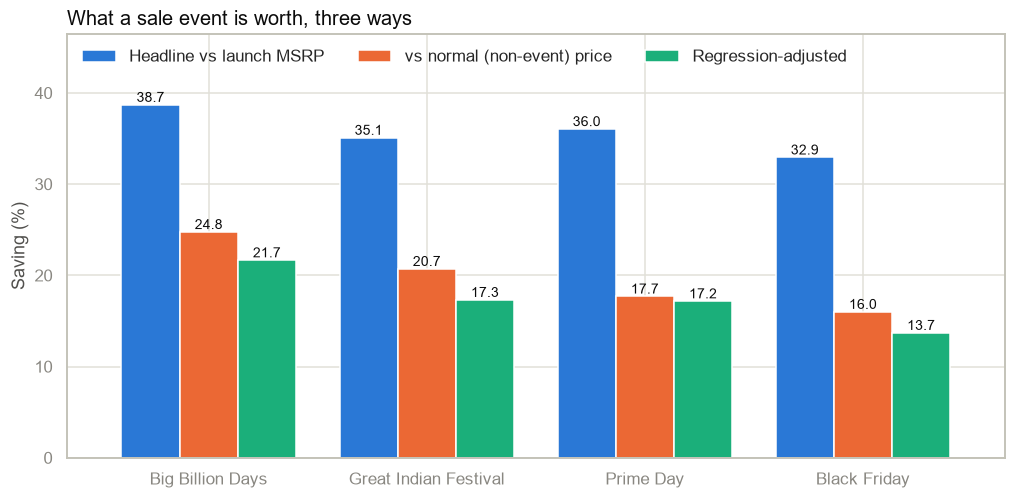

,headline_vs_msrp_pct,saving_vs_normal_pct,regression_saving_pct
sale_event,,,
Big Billion Days,38.69,24.75,21.65
Great Indian Festival,35.08,20.70,17.30
Prime Day,36.04,17.68,17.16
Black Friday,32.92,16.00,13.69


In [14]:
comparison = event_summary.drop(index="No Event")[["headline_vs_msrp_pct", "saving_vs_normal_pct"]].join(
    -effects("sale_event")["effect_pct"].rename("regression_saving_pct")
)
fig, ax = plt.subplots(figsize=(11, 5))
comparison.plot.bar(ax=ax, color=SERIES, width=0.8, rot=0)
ax.set(title="What a sale event is worth, three ways", ylabel="Saving (%)", xlabel="")
ax.set_ylim(0, comparison.to_numpy().max() * 1.2)
ax.legend(["Headline vs launch MSRP", "vs normal (non-event) price", "Regression-adjusted"], frameon=False, ncol=3, loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9, color="#0b0b0b")
save(fig, "sale_event_savings")
plt.show()
comparison

**Finding.** Headline discounts of 33–39% overstate the benefit: roughly half is depreciation the product
had already accumulated. Against the product's normal price, events save **16–25%**, and the regression
(controlling for model, age, platform, condition and season) gives a consistent **14–22%**.
**Big Billion Days** is the strongest event and **Black Friday** the weakest, but on ~99% of event days the
saving is at least 5% — events are reliably worth waiting for if one is coming soon.

## 6. Amazon vs Flipkart

In [15]:
gaps = sql("select * from marts.mart_platform_price_gap")
non_tied = gaps[gaps["gap_usd"] != 0]
stat, p_value = wilcoxon(non_tied["amazon_price_usd"], non_tied["flipkart_price_usd"])
rng = np.random.default_rng(42)
boot = [np.median(rng.choice(gaps["gap_pct"], len(gaps))) for _ in range(1000)]

print(f"Matched product-days: {len(gaps):,}")
print(f"Amazon cheaper: {(gaps['cheaper_platform'] == 'Amazon').mean():.1%}")
print(f"Median gap: {gaps['gap_pct'].median():+.3f}%  (95% bootstrap CI {np.percentile(boot, 2.5):+.3f}% to {np.percentile(boot, 97.5):+.3f}%)")
print(f"Wilcoxon signed-rank p = {p_value:.3f}")
print(f"Mean absolute gap on a given day: {gaps['gap_pct'].abs().mean():.2f}%")
print("Regression platform effect (Flipkart vs Amazon):")
effects("platform")

Matched product-days: 12,669
Amazon cheaper: 50.4%
Median gap: -0.014%  (95% bootstrap CI -0.054% to +0.025%)
Wilcoxon signed-rank p = 0.235
Mean absolute gap on a given day: 2.72%
Regression platform effect (Flipkart vs Amazon):


,effect_pct,ci_low_pct,ci_high_pct,p_value
Flipkart,0.03,-0.06,0.11,0.54


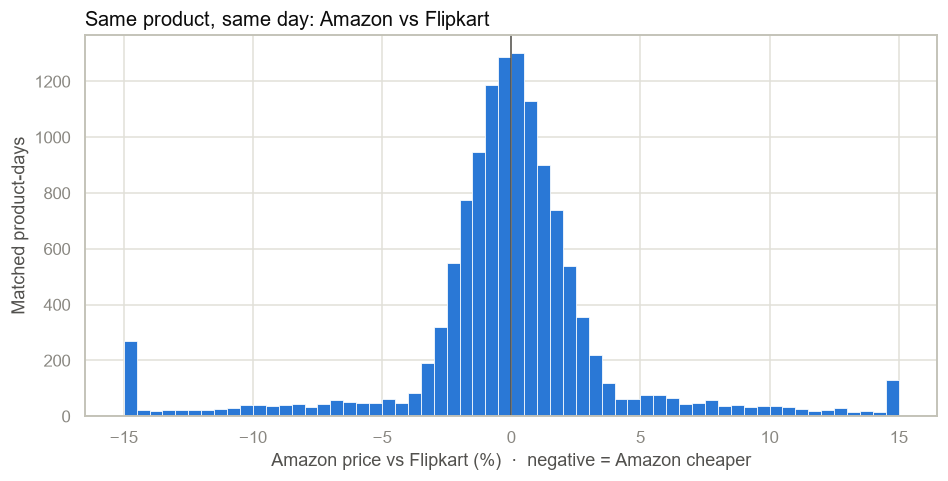

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(gaps["gap_pct"].clip(-15, 15), bins=60, color=SERIES[0], edgecolor="white", linewidth=0.5)
ax.axvline(0, color="#52514e", lw=1)
ax.set(title="Same product, same day: Amazon vs Flipkart", xlabel="Amazon price vs Flipkart (%)  ·  negative = Amazon cheaper",
       ylabel="Matched product-days")
save(fig, "platform_gap")
plt.show()

**Finding.** Neither marketplace is systematically cheaper: the median matched gap is ~0% with a 95% CI
within ±0.06%, the paired test is not significant, and the regression effect is 0.03% (p = 0.54). But on any given
day the two differ by **~2.7%** in a random direction — so the actionable advice is simply to check both.

## 7. New vs refurbished

In [17]:
refurb = sql("""
    select n.product_category,
           avg((n.median_price_usd - r.median_price_usd) / n.median_price_usd * 100) as refurbished_discount_pct,
           count(*) as matched_days
    from marts.fct_daily_market_prices n
    join marts.fct_daily_market_prices r
      on n.price_date = r.price_date and n.platform = r.platform and n.model_name = r.model_name
    where n.condition = 'New' and r.condition = 'Refurbished'
    group by 1
""").set_index("product_category").loc[CATEGORY_ORDER]
display(refurb)
effects("condition")

,refurbished_discount_pct,matched_days
product_category,,
iPhone,22.50,3329
iPad,22.49,1600
Mac,22.62,2161
Watch,22.68,2078


,effect_pct,ci_low_pct,ci_high_pct,p_value
Refurbished,-22.72,-22.82,-22.63,0.00


**Finding.** A refurbished unit costs **~22–23% less** than a new one of the same model on the same platform
and day, consistently across categories (regression: −22.7%, tight CI). Combined with section 4, a
refurbished previous-generation iPhone bought after the successor launch is ~35% below the new price.

## 8. Stock status — a confounding trap

A naive comparison suggests out-of-stock listings are ~10 index points cheaper. Is scarcity lowering prices?

In [18]:
naive = obs.groupby("stock_status").agg(avg_price_index=("price_index", "mean"),
                                        avg_days_since_release=("days_since_release", "mean"))
display(naive)
effects("stock_status")

,avg_price_index,avg_days_since_release
stock_status,,
In Stock,81.58,569.32
Low Stock,72.72,909.77
Out of Stock,71.33,969.64


,effect_pct,ci_low_pct,ci_high_pct,p_value
Low Stock,-0.08,-0.22,0.05,0.23
Out of Stock,0.00,-0.13,0.13,0.97


**Finding.** No. Out-of-stock and low-stock listings are simply **older products** (≈ 950 vs 570 days since
release), and older products are cheaper. Once model, age and season are controlled, the stock effect
disappears (**−0.1% and 0.0%, not significant**). The raw correlation was driven by product age, not
scarcity — a reminder to control for confounders before reading causation into a group comparison.

## 9. Price forecasting (7 and 30 days)

Trained by `apple_pricing.forecasting.train` on the series-day fact:

- **Features** in *calendar time* via as-of joins (the series are irregular, so "7-day lag" means the last
  price at least 7 days ago, not 7 rows ago): returns over 7/14/30/60 days, position vs 7/30/90-day rolling
  mean/min/max, volatility, the other marketplace's price, release/successor age, sale event, calendar.
- **Target** log(future price / current price), so one model serves $329 and $1,999 products.
- **Model** CatBoost MultiQuantile → P10 / P50 / P90; P50 is the point forecast.
- **Validation** chronological train / validation / test with an embargo of horizon + 3 days between folds;
  test = last 180 days. Early stopping on validation only.
- **Intervals** calibrated with split-conformal adjustment on the validation fold.
- **Baselines** naive last price and trailing 30-day mean — the model has to beat the *stronger* one.

In [19]:
metrics = json.loads((PROJECT_DIR / "data" / "marts" / "model_metrics.json").read_text())
summary = pd.DataFrame({
    h: {
        "model_MAE": m["model"]["MAE"],
        "naive_MAE": m["baseline_naive_last_price"]["MAE"],
        "trailing_30d_MAE": m["baseline_trailing_30d_mean"]["MAE"],
        "improvement_vs_naive_pct": m["mae_improvement_vs_naive_pct"],
        "improvement_vs_trailing_pct": m["mae_improvement_vs_trailing_30d_pct"],
        "WAPE_pct": m["model"]["WAPE_pct"],
        "P10_P90_coverage_pct": m["p10_p90_interval_coverage_pct"],
        "raw_quantile_coverage_pct": m["p10_p90_raw_quantile_coverage_pct"],
        "test_rows": m["rows"]["test"],
    }
    for h, m in metrics["horizons"].items()
})
summary

,7d,30d
model_MAE,14.60,16.70
naive_MAE,23.21,21.35
trailing_30d_MAE,18.12,18.30
improvement_vs_naive_pct,37.09,21.77
improvement_vs_trailing_pct,19.41,8.73
WAPE_pct,1.95,2.23
P10_P90_coverage_pct,84.34,82.80
raw_quantile_coverage_pct,77.73,70.76
test_rows,"7,431.00","7,362.00"


In [20]:
per_category = pd.concat(
    {h: pd.DataFrame(m["mae_by_category"]).T for h, m in metrics["horizons"].items()}, names=["horizon"]
)
per_category

model_mae  naive_mae  trailing_30d_mae
horizon                                               
7d      Mac         26.52      42.48             34.23
        Watch        6.37      10.18              7.71
        iPad        11.90      18.88             15.67
        iPhone      13.23      20.82             15.37
30d     Mac         30.91      40.38             35.37
        Watch        6.86       9.02              7.24
        iPad        14.33      17.41             17.14
        iPhone      14.78      18.60             14.92

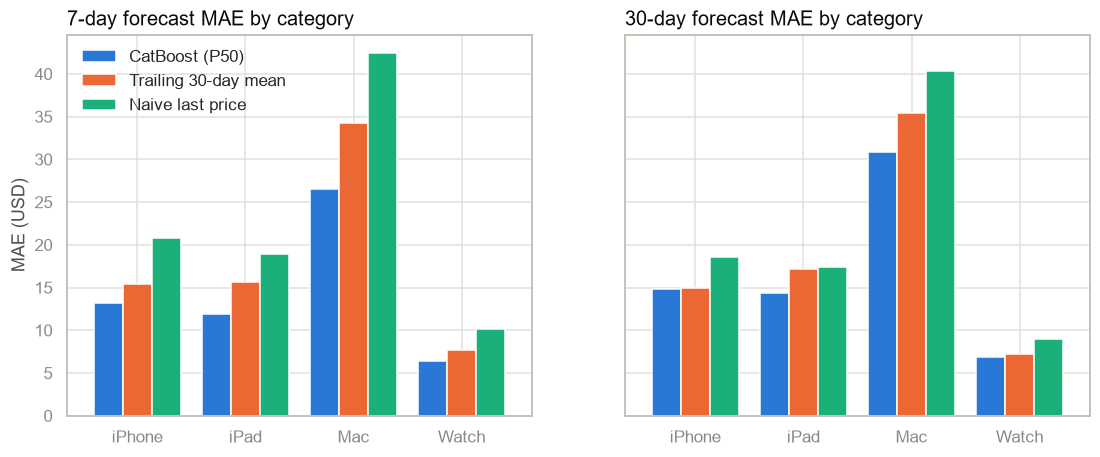

In [21]:
backtest = sql("select * from marts.mart_forecast_backtest")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, horizon in zip(axes, [7, 30]):
    part = backtest[backtest["horizon_days"] == horizon]
    mae = part.groupby("product_category")[["model_abs_error_usd", "trailing_abs_error_usd", "naive_abs_error_usd"]].mean()
    mae.loc[CATEGORY_ORDER].plot.bar(ax=ax, color=SERIES, rot=0, width=0.8, legend=False)
    ax.set(title=f"{horizon}-day forecast MAE by category", xlabel="", ylabel="MAE (USD)")
axes[0].legend(["CatBoost (P50)", "Trailing 30-day mean", "Naive last price"], frameon=False)
save(fig, "forecast_mae_by_category")
plt.show()

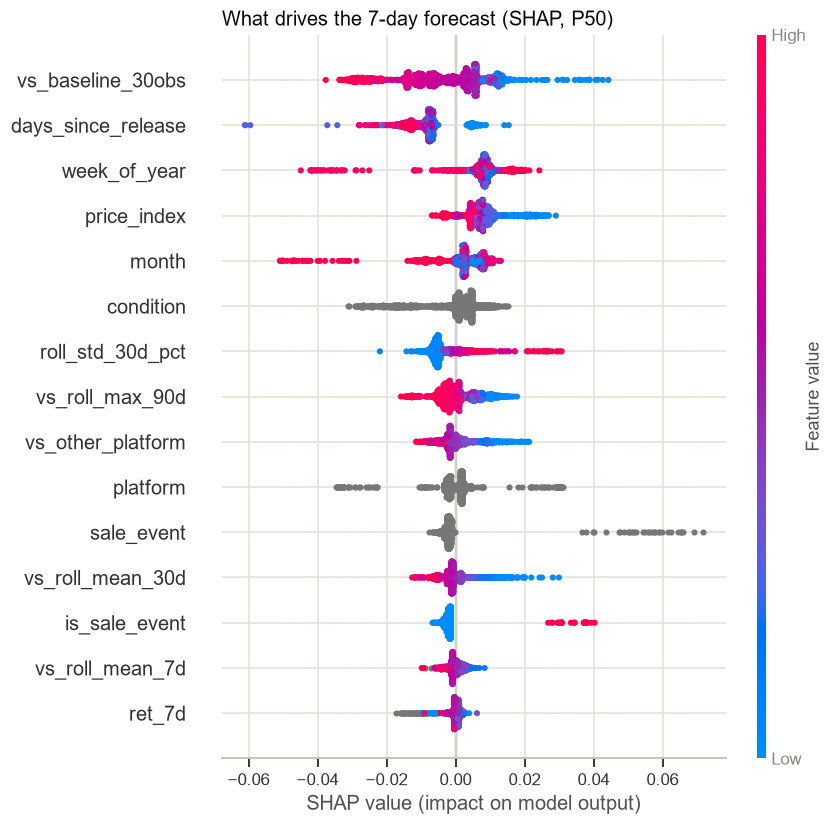

In [22]:
import shap
from catboost import CatBoostRegressor, Pool

from apple_pricing.forecasting.features import CATEGORICAL_FEATURES, MODEL_FEATURES, build_features, load_daily
from apple_pricing.warehouse import DuckDBWarehouse

class _ReadOnly(DuckDBWarehouse):
    def __init__(self):
        self.connection = con

features = build_features(load_daily(_ReadOnly()))
model = CatBoostRegressor()
model.load_model(str(PROJECT_DIR / "artifacts" / "models" / "price_forecast_7d_backtest.cbm"))

sample = features[features["price_date"] >= metrics["horizons"]["7d"]["split"]["test_start"]].sample(1500, random_state=42)
shap_values = model.get_feature_importance(Pool(sample[MODEL_FEATURES], cat_features=CATEGORICAL_FEATURES), type="ShapValues")
# MultiQuantile returns one SHAP matrix per quantile; explain the median (P50).
median_shap = shap_values[:, 1, :-1] if shap_values.ndim == 3 else shap_values[:, :-1]

shap.summary_plot(median_shap, sample[MODEL_FEATURES], max_display=15, show=False)
plt.title("What drives the 7-day forecast (SHAP, P50)")
save(plt.gcf(), "shap_7d")
plt.show()

**Findings.**
- The 7-day model cuts MAE by **~37% vs the naive last price** and **~19% vs a trailing 30-day mean**;
  the 30-day model by **~22%** and **~9%**. Reporting both baselines matters: most of the gain over "last price"
  comes from smoothing listing noise, and the honest value-add of ML is the gain over the smoothed baseline.
- Error is ~2% of price (WAPE) and largest in dollars for Mac (highest prices).
- Raw quantile intervals under-covered (71–78% vs 80% nominal); conformal calibration brings coverage to
  ~83–84% on the unseen test window.
- SHAP shows two mechanisms. **Mean reversion**: the strongest driver is how far today's price is from its
  normal (non-event) level — a price well below normal is predicted to bounce back, which is exactly the
  buy-now signal. **Timing**: days since release, week of year and month capture sale seasons and the
  September launch cycle, and an active sale event predicts a rebound once it ends.

## 10. Buy-now / wait recommendations

In [23]:
deals = sql("select * from marts.mart_deal_scores")
print(deals["recommendation"].value_counts().to_string())
deals.sort_values("deal_score", ascending=False)[
    ["series_id", "current_price_usd", "discount_vs_normal_pct", "forecast_30d_usd",
     "forecast_30d_p10_usd", "forecast_30d_p90_usd", "recommendation", "deal_score"]
].head(10)

recommendation
No rush    68
Wait       28
Buy now    28


,series_id,current_price_usd,discount_vs_normal_pct,forecast_30d_usd,forecast_30d_p10_usd,forecast_30d_p90_usd,recommendation,deal_score
30,Flipkart | Apple Watch Series 9 (45mm) | Refur...,182.22,9.66,199.12,184.52,216.75,Buy now,89.90
21,Amazon | MacBook Pro 14-inch M3 Pro 512GB | Re...,"1,246.09",11.18,"1,318.19","1,238.95","1,450.43",Buy now,89.50
22,Flipkart | iPhone 15 Pro Max 256GB | Refurbished,712.78,9.46,755.13,701.32,825.08,Buy now,88.20
18,Flipkart | Apple Watch Series X (45mm) | Refur...,235.64,6.87,251.36,233.50,275.23,Buy now,86.60
56,Flipkart | Apple Watch Series 7 (45mm) | Refur...,189.65,5.58,194.86,183.56,211.96,Buy now,86.40
90,Flipkart | iPhone 15 128GB | Refurbished,451.76,2.23,465.60,434.82,497.89,Buy now,85.90
123,Flipkart | iPad Pro 11-inch (M4) 256GB | New,787.20,1.69,798.81,788.30,811.95,Buy now,81.60
40,Amazon | iPhone 14 Pro 128GB | Refurbished,489.16,10.93,524.02,495.24,572.96,Buy now,81.30
24,Flipkart | iPhone 13 128GB | Refurbished,347.84,7.81,380.28,353.16,406.73,Buy now,79.10
15,Flipkart | iPad Pro 11-inch (M4) 256GB | Refur...,573.65,9.88,607.85,562.28,662.77,Buy now,78.50


Rules live in the dbt model `mart_deal_scores` (versioned and tested): **Buy now** when today's price is below
the calibrated 30-day P10, the forecast expects a rise of 2%+, or the price is 5%+ below normal; **Wait** when
the price is above the 30-day P90 or a 3%+ drop is expected; otherwise **No rush**.

## 11. Conclusions

| # | Question | Answer |
|---|---|---|
| 1 | Which category holds value best? | **Mac** — above 90% of MSRP for two years; iPhone/iPad/Watch fall below 90% at month 12. |
| 2 | How do prices decline? | In **annual steps** at each successor launch, flattening near 60% of MSRP after ~3 years. |
| 3 | What does a successor launch do? | Previous model drops **~15% (iPhone)** and **~20% (Watch)** within 60 days; Mac ≈ 0%. |
| 4 | How much do sale events save? | Headline 33–39% vs MSRP, but **16–25% vs the normal price** (14–22% regression-adjusted). Big Billion Days best, Black Friday weakest. |
| 5 | Is Amazon or Flipkart cheaper? | **Neither** systematically (p = 0.24), but they differ by ~2.7% on a given day — compare both. |
| 6 | New vs refurbished? | Refurbished is **~22–23% cheaper** for the same model, platform and day. |
| 7 | Does stock status move prices? | No: the raw 10-point gap is **confounded by product age**; the controlled effect is ≈ 0% and not significant. |
| 8 | Can prices be forecast? | Yes: 7-day MAE **$14.60** (−37% vs naive, −19% vs 30-day mean) with calibrated 80% intervals. |

**Recommendations**
- *Buyers:* buy the outgoing iPhone/Watch in the two months after its successor launches, or wait for Big Billion
  Days / Great Indian Festival; consider refurbished for a further ~22%; check both marketplaces on the day.
- *Retailers / category managers:* expect a 15–20% price reset on outgoing iPhone/Watch stock at launch —
  clear inventory beforehand; Mac inventory carries far less launch risk.

**Limitations**
- The dataset shows signs of being simulated (section 1), so effect sizes are specific to it.
- No seller, shipping, bank-offer or exchange-bonus data; "price" is the listed price.
- Forecast accuracy is measured on one 180-day test window; a rolling-origin backtest would give error bands.